# AI-Powered Smart Grid Monitoring System

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv("data/PJME_hourly.csv")
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB


In [4]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')

In [5]:
df = df.sort_index()

In [6]:
df.isnull().sum()

PJME_MW    0
dtype: int64

In [7]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [8]:
print(df.index.min())
print(df.index.max())

2002-01-01 01:00:00
2018-08-03 00:00:00


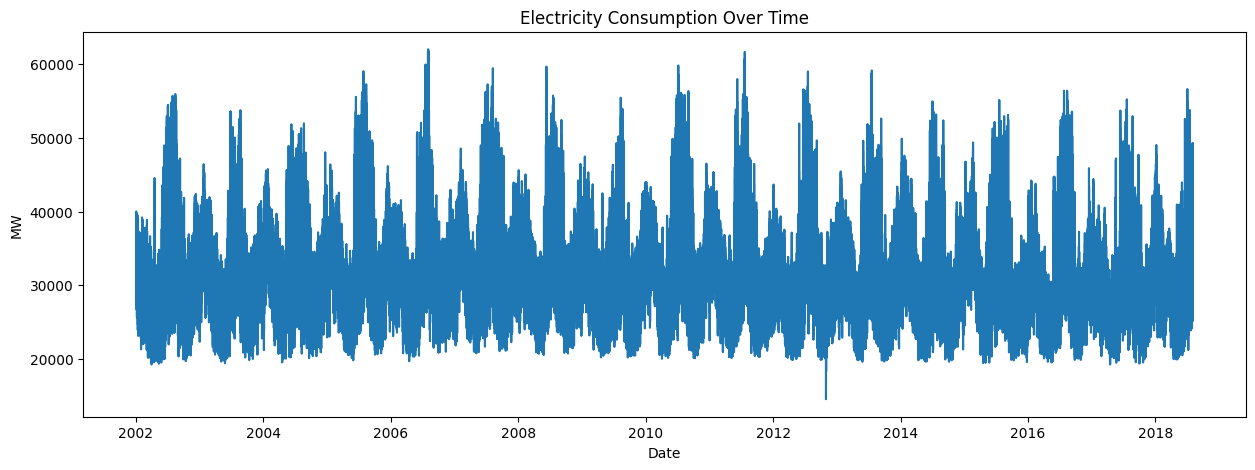

In [9]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['PJME_MW'])
plt.title("Electricity Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("MW")
plt.show()

In [10]:
# Step 5 — Resample

In [11]:
daily_df = df.resample('D').mean()

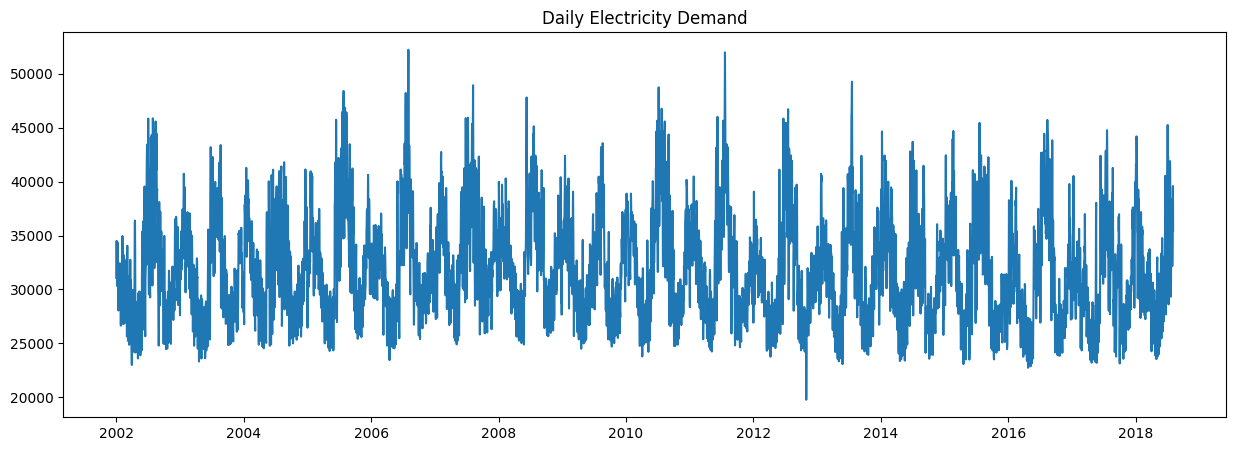

In [12]:
plt.figure(figsize=(15,5))
plt.plot(daily_df.index, daily_df['PJME_MW'])
plt.title("Daily Electricity Demand")
plt.show()

# Step 6 — Time Series Decomposition


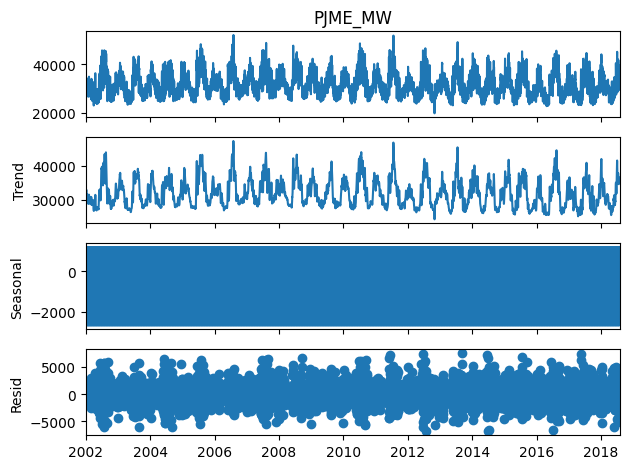

In [13]:
decomposition = seasonal_decompose(daily_df['PJME_MW'], model='additive')

decomposition.plot()
plt.show()

In [14]:
# Step 7 — Stationarity Test (Very Important)

In [15]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_df['PJME_MW'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -8.262176673539571
p-value: 5.048771728308097e-13


In [16]:
# Step 8 — Differencing

In [17]:
daily_df['diff'] = daily_df['PJME_MW'].diff()
daily_df = daily_df.dropna()

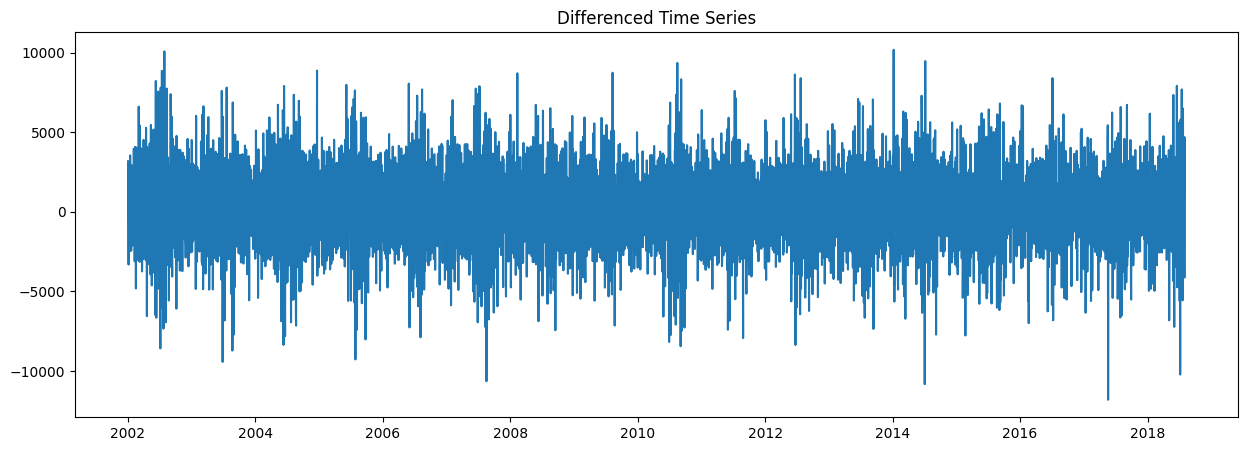

In [18]:
plt.figure(figsize=(15,5))
plt.plot(daily_df['diff'])
plt.title("Differenced Time Series")
plt.show()

In [19]:
#Step 9 — ACF and PACF (for SARIMA)

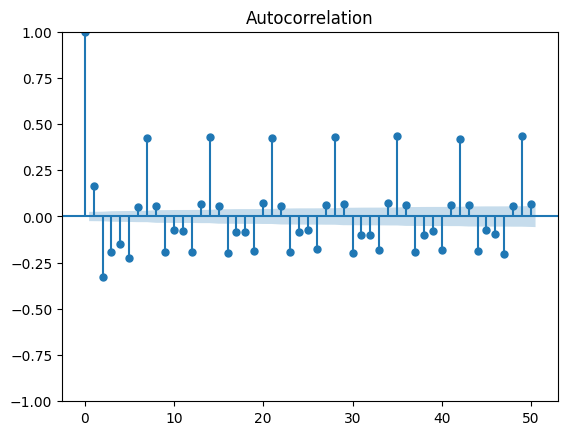

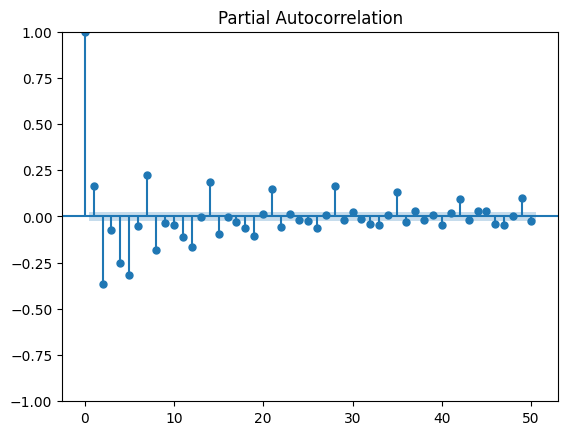

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(daily_df['diff'], lags=50)
plot_pacf(daily_df['diff'], lags=50)

plt.show()

In [21]:
# Step 10 — Train/Test Split (Time Series Style)

In [22]:
train_size = int(len(daily_df) * 0.8)

train = daily_df['PJME_MW'][:train_size]
test = daily_df['PJME_MW'][train_size:]

In [23]:
print(len(train), len(test))

4846 1212


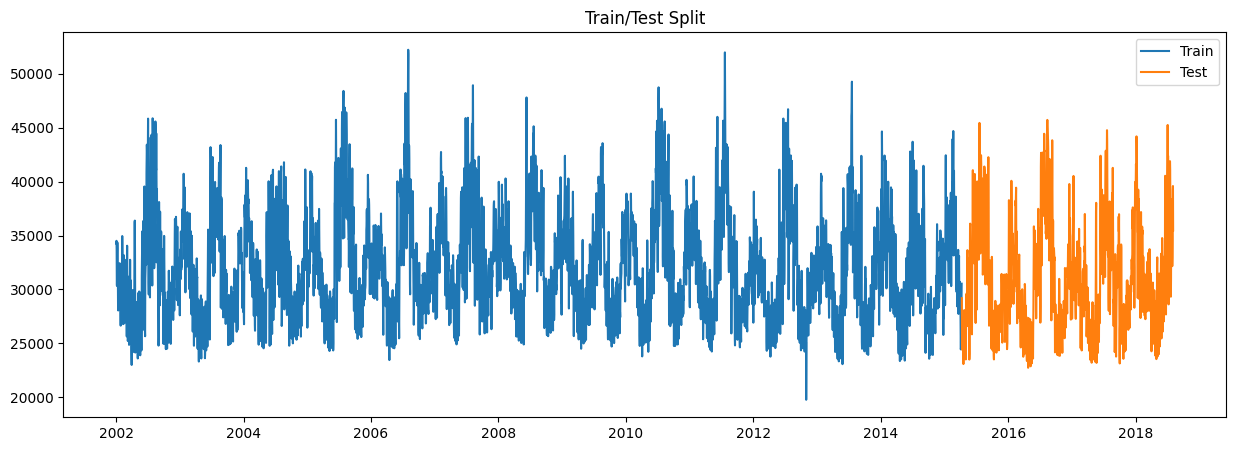

In [24]:
plt.figure(figsize=(15,5))

plt.plot(train, label="Train")
plt.plot(test, label="Test")

plt.legend()
plt.title("Train/Test Split")
plt.show()

In [25]:
# Step 11 — Understanding SARIMA

In [26]:
# Step 12 — Build the SARIMA Model

In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [28]:
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

sarima_model = model.fit()

c:\ai-smart-grid-monitoring\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [29]:
print(sarima_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           PJME_MW   No. Observations:                 4846
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -43157.997
Date:                           Fri, 10 Apr 2026   AIC                          86325.994
Time:                                   10:57:50   BIC                          86358.416
Sample:                               01-02-2002   HQIC                         86337.376
                                    - 04-09-2015                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3109      0.037     -8.472      0.000      -0.383      -0.239
ma.L1          0.5692      0.033     17.435

In [30]:
# Step 13 — Forecast Electricity Demand

In [31]:
predictions = sarima_model.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    dynamic=False
)

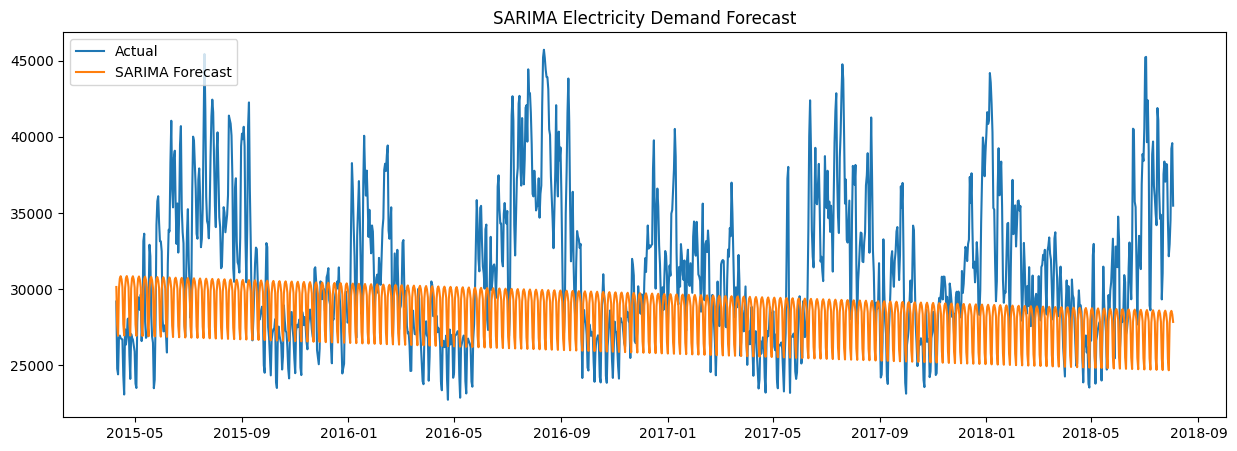

In [32]:
plt.figure(figsize=(15,5))

plt.plot(test.index, test, label="Actual")
plt.plot(test.index, predictions, label="SARIMA Forecast")

plt.legend()
plt.title("SARIMA Electricity Demand Forecast")
plt.show()

In [33]:
# step 14 — Model Evaluation

In [34]:
rmse = np.sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

RMSE: 5388.275779533627


In [35]:
mae = mean_absolute_error(test, predictions)
print("MAE:", mae)

MAE: 4092.0755516713916


In [36]:
#Step 15 — Residual Analysis (Important for Anomaly Detection)

In [37]:
residuals = test - predictions

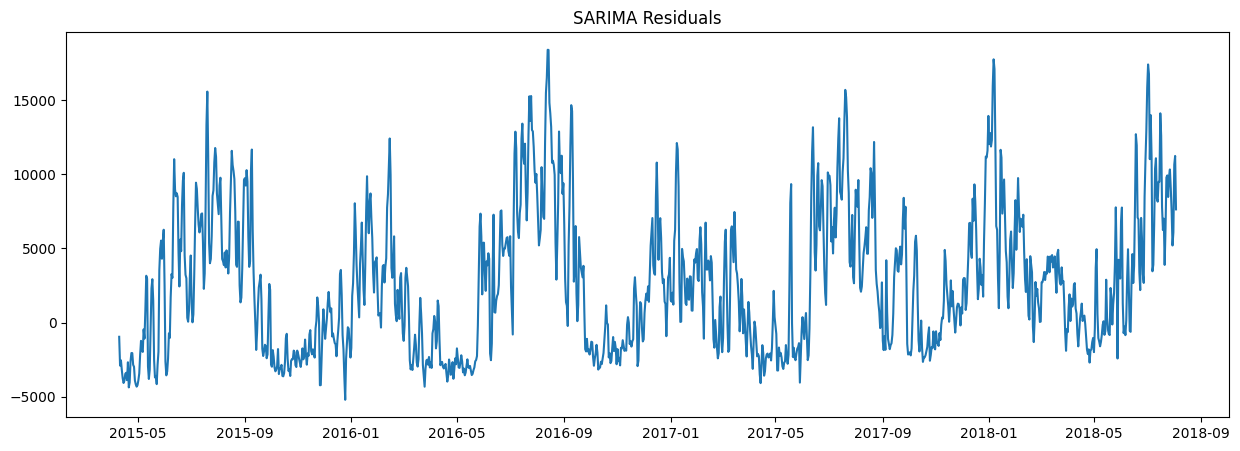

In [38]:
plt.figure(figsize=(15,5))
plt.plot(residuals)
plt.title("SARIMA Residuals")
plt.show()

In [39]:
#  Step 16 — Detect Anomalies Using Residuals

In [40]:
threshold = 3 * residuals.std()

In [41]:
#Detect anomalies.

anomalies = residuals[np.abs(residuals) > threshold]

print("Number of anomalies:", len(anomalies))

Number of anomalies: 20


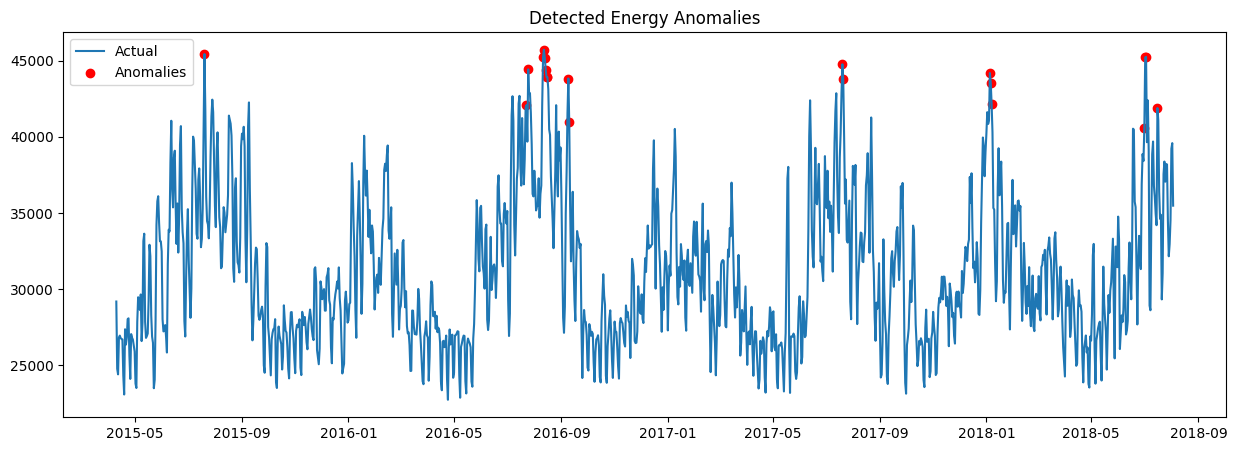

In [42]:
plt.figure(figsize=(15,5))

plt.plot(test.index, test, label="Actual")
plt.scatter(anomalies.index, test.loc[anomalies.index],
            color="red", label="Anomalies")

plt.legend()
plt.title("Detected Energy Anomalies")
plt.show()

In [43]:
#Step 18 — Scale the Data

In [44]:
from sklearn.preprocessing import MinMaxScaler

In [45]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
test_scaled = scaler.transform(test.values.reshape(-1,1))

In [46]:
# Step 19 — Create Sequences

In [47]:
window = 30

def create_sequences(data, window):

    X = []
    y = []

    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [48]:
X_train, y_train = create_sequences(train_scaled, window)
X_test, y_test = create_sequences(test_scaled, window)

print(X_train.shape)
print(X_test.shape)

(4816, 30, 1)
(1182, 30, 1)


In [49]:
#Step 20 — Build the LSTM Model

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [51]:
#Create the model.

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(window,1)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

c:\ai-smart-grid-monitoring\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [52]:
#Compile.

model.compile(
    optimizer="adam",
    loss="mse"
)

In [53]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
#Step 21 — Train the Model

In [55]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0158 - val_loss: 0.0104
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0116 - val_loss: 0.0112
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0111 - val_loss: 0.0098
Epoch 4/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0106 - val_loss: 0.0101
Epoch 5/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0103 - val_loss: 0.0094
Epoch 6/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0100 - val_loss: 0.0088
Epoch 7/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0094 - val_loss: 0.0082
Epoch 8/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0085 - val_loss: 0.0071
Epoch 9/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0072 - val_loss: 0.0060
Epoch 10/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0065 - val_loss: 0.0055
Epoch 11/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0060 - val_loss: 0.0052
Epoch 12/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/ste

In [56]:
# Step 22 — Generate Predictions from the LSTM

In [57]:
lstm_pred = model.predict(X_test)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [58]:
#Verify the shape
#Immediately check this:

print(lstm_pred.shape)
print(y_test.shape)

(1182, 1)
(1182, 1)


In [59]:
# Step 23 — Convert Predictions Back to Real MW Values

In [60]:
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test)

In [61]:
#Verify it worked


print(lstm_pred_actual[:5])
print(y_test_actual[:5])

[[26467.03 ]
 [28393.201]
 [32904.953]
 [31967.027]
 [27184.812]]
[[27798.83333333]
 [33162.91666667]
 [33645.125     ]
 [27868.70833333]
 [26802.08333333]]


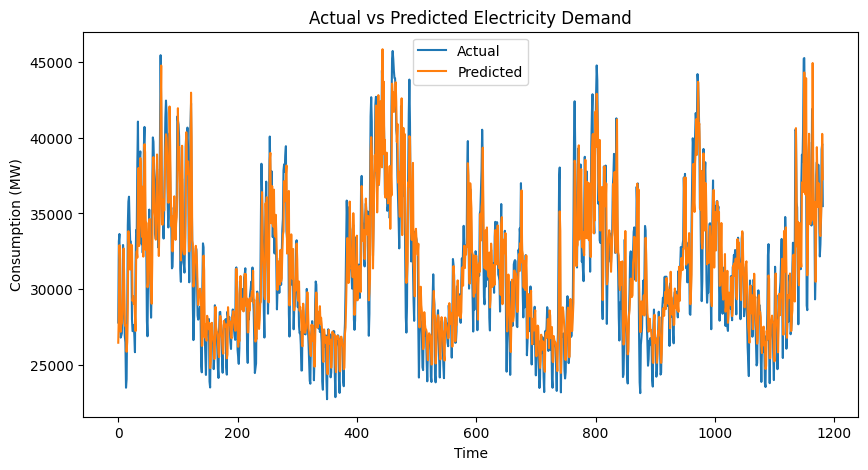

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label="Actual")
plt.plot(lstm_pred_actual, label="Predicted")

plt.title("Actual vs Predicted Electricity Demand")
plt.xlabel("Time")
plt.ylabel("Consumption (MW)")

plt.legend()

# save image
plt.savefig("images/forecast_vs_actual.png")

plt.show()

In [62]:
#Step 24 — Plot LSTM Predictions vs Real Demand

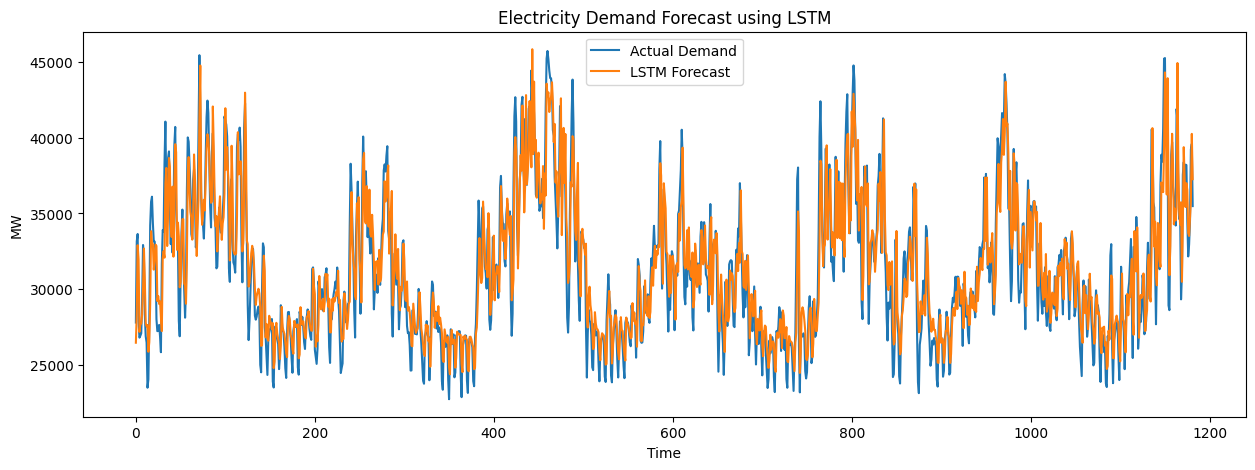

In [63]:
plt.figure(figsize=(15,5))

plt.plot(y_test_actual, label="Actual Demand")
plt.plot(lstm_pred_actual, label="LSTM Forecast")

plt.title("Electricity Demand Forecast using LSTM")
plt.xlabel("Time")
plt.ylabel("MW")
plt.legend()

plt.show()

In [64]:
# Step 25 — Evaluate the LSTM Model (RMSE & MAE)

In [65]:
#Now we calculate the error metrics so we can compare with your SARIMA model.

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [66]:
#Calculate RMSE
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, lstm_pred_actual))
print("LSTM RMSE:", rmse_lstm)
#Calculate MAE
mae_lstm = mean_absolute_error(y_test_actual, lstm_pred_actual)
print("LSTM MAE:", mae_lstm)

LSTM RMSE: 2177.1603248720794
LSTM MAE: 1672.566606282109


# Step 26 — Compare SARIMA vs LSTM

In [67]:
results = pd.DataFrame({
    "Model": ["SARIMA", "LSTM"],
    "RMSE": [rmse, rmse_lstm],
    "MAE": [mae, mae_lstm]
})

print(results)

    Model         RMSE          MAE
0  SARIMA  5388.275780  4092.075552
1    LSTM  2177.160325  1672.566606


In [68]:
# Step 27 — LSTM Autoencoder (Anomaly Detection)

In [69]:
from tensorflow.keras.layers import RepeatVector, TimeDistributed

In [70]:
window = 30

data_scaled = scaler.fit_transform(df['PJME_MW'].values.reshape(-1,1))

X_auto, _ = create_sequences(data_scaled, window)

print(X_auto.shape)

(145336, 30, 1)


In [71]:
# Step 28 — Build the LSTM Autoencoder

In [72]:
autoencoder = Sequential()

# Encoder
autoencoder.add(LSTM(64, activation='relu', input_shape=(window,1), return_sequences=True))
autoencoder.add(LSTM(32, activation='relu', return_sequences=False))

# Bottleneck
autoencoder.add(RepeatVector(window))

# Decoder
autoencoder.add(LSTM(32, activation='relu', return_sequences=True))
autoencoder.add(LSTM(64, activation='relu', return_sequences=True))

autoencoder.add(TimeDistributed(Dense(1)))

c:\ai-smart-grid-monitoring\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [73]:
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

In [74]:
autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,529 (244.25 KB)

 Trainable params: 62,529 (244.25 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
# Step 29 — Train the Autoencoder

In [76]:
history_auto = autoencoder.fit(
    X_auto,
    X_auto,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - loss: 0.0046 - val_loss: 9.3540e-04
Epoch 2/10
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 5.4859e-04 - val_loss: 4.9216e-04
Epoch 3/10
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 3.7332e-04 - val_loss: 3.9305e-04
Epoch 4/10
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 2.9984e-04 - val_loss: 3.2506e-04
Epoch 5/10
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 2.5416e-04 - val_loss: 2.7582e-04
Epoch 6/10
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 2.0858e-04 - val_loss: 2.1762e-04
Epoch 7/10
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 1.7135e-04 - val_loss: 1.7147e-04
Epoch 8/10
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 1.3732e-04 - val_loss: 1.4012e-04
Epoch 9/10
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 1.1671e-04 - val_loss: 1.3211e-04
Epoch 10/10
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 1.0388e-04 - val_loss: 1.1357e-04


In [77]:
# Step 30 — Compute Reconstruction Error

In [78]:
X_pred = autoencoder.predict(X_auto)

4542/4542 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step


In [79]:
reconstruction_error = np.mean(
    np.abs(X_pred - X_auto),
    axis=(1,2)
)

In [80]:
# Check the error values

print(reconstruction_error[:10])

[0.00761629 0.01197639 0.01507616 0.01357154 0.01186217 0.01076378
 0.00892307 0.00843762 0.00859226 0.0080742 ]


In [81]:
# Step 31 — Define the Anomaly Threshold

In [82]:
threshold = np.mean(reconstruction_error) + 3*np.std(reconstruction_error)

print("Anomaly Threshold:", threshold)

Anomaly Threshold: 0.014354165900767282


In [83]:
# Now detect anomalies

anomalies = reconstruction_error > threshold

print("Number of anomalies detected:", np.sum(anomalies))

Number of anomalies detected: 1988


In [84]:
# Step 32 — Locate Where the Anomalies Occur

In [85]:
anomaly_indices = np.where(anomalies)[0]

print(anomaly_indices[:10])

[  2 423 461 462 463 469 470 471 472 642]


In [86]:
# Convert them back to time positions

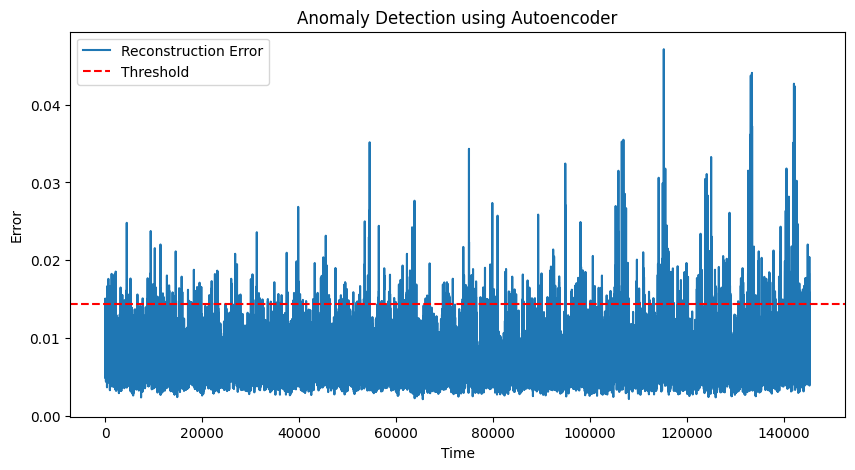

In [118]:
plt.figure(figsize=(10,5))

plt.plot(reconstruction_error, label="Reconstruction Error")

plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold")

plt.title("Anomaly Detection using Autoencoder")
plt.xlabel("Time")
plt.ylabel("Error")

plt.legend()

plt.savefig("images/anomaly_detection.png")

plt.show()

In [87]:
anomaly_timestamps = df.index[anomaly_indices + window]

print(anomaly_timestamps[:10])

DatetimeIndex(['2002-01-02 09:00:00', '2002-01-19 22:00:00',
               '2002-01-21 12:00:00', '2002-01-21 13:00:00',
               '2002-01-21 14:00:00', '2002-01-21 20:00:00',
               '2002-01-21 21:00:00', '2002-01-21 22:00:00',
               '2002-01-21 23:00:00', '2002-01-29 01:00:00'],
              dtype='datetime64[us]', name='Datetime', freq=None)


In [88]:
# Step 33 — Visualize the Detected Anomalies

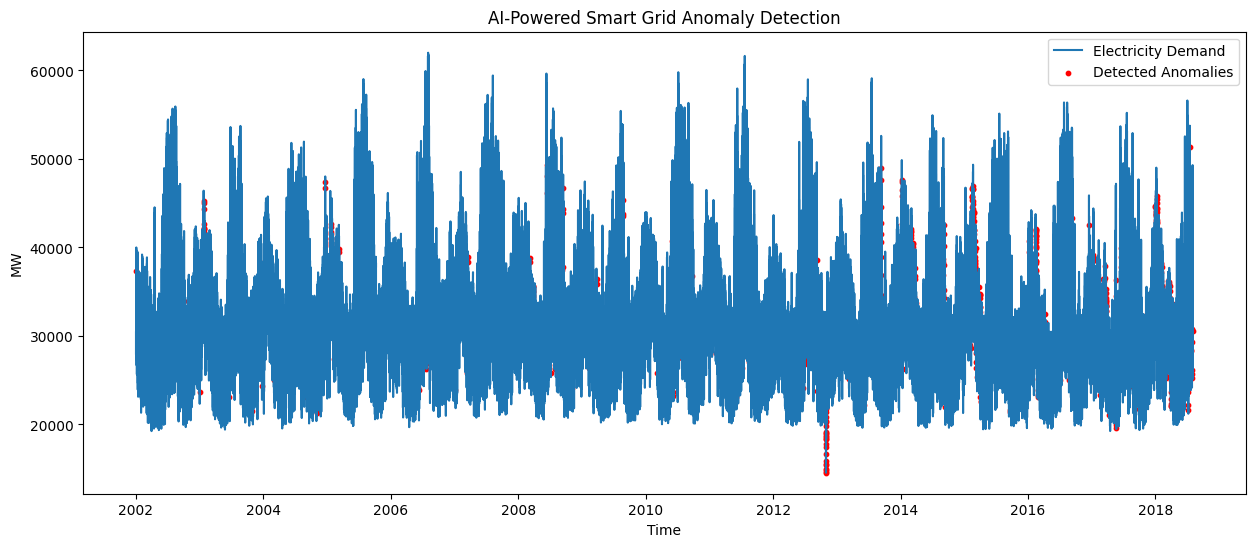

In [89]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df['PJME_MW'], label="Electricity Demand")

plt.scatter(
    anomaly_timestamps,
    df.loc[anomaly_timestamps]['PJME_MW'],
    color='red',
    label="Detected Anomalies",
    s=10
)

plt.title("AI-Powered Smart Grid Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("MW")
plt.legend()

plt.show()

In [90]:
# Final Step — Step 34: Create an Anomaly Summary Table

In [91]:
anomaly_data = pd.DataFrame({
    "timestamp": anomaly_timestamps,
    "demand_MW": df.loc[anomaly_timestamps]["PJME_MW"]
})

print(anomaly_data.head())

                              timestamp  demand_MW
Datetime                                          
2002-01-02 09:00:00 2002-01-02 09:00:00    37322.0
2002-01-19 22:00:00 2002-01-19 22:00:00    32986.0
2002-01-21 12:00:00 2002-01-21 12:00:00    36358.0
2002-01-21 13:00:00 2002-01-21 13:00:00    35528.0
2002-01-21 14:00:00 2002-01-21 14:00:00    34665.0


In [92]:
anomaly_data = anomaly_data.sort_values(by="demand_MW", ascending=False)

print(anomaly_data.head(10))

                              timestamp  demand_MW
Datetime                                          
2012-07-07 19:00:00 2012-07-07 19:00:00    52174.0
2018-07-16 14:00:00 2018-07-16 14:00:00    51410.0
2010-06-28 19:00:00 2010-06-28 19:00:00    50331.0
2012-07-27 14:00:00 2012-07-27 14:00:00    49985.0
2012-07-18 19:00:00 2012-07-18 19:00:00    49892.0
2010-07-24 11:00:00 2010-07-24 11:00:00    49433.0
2008-06-11 18:00:00 2008-06-11 18:00:00    49310.0
2010-06-28 20:00:00 2010-06-28 20:00:00    49111.0
2013-09-10 18:00:00 2013-09-10 18:00:00    48931.0
2012-07-18 20:00:00 2012-07-18 20:00:00    48527.0


In [93]:
%pip install --upgrade nbformat



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [94]:
import plotly.express as px

fig = px.line(df, x=df.index, y="PJME_MW",
              title="Smart Grid Electricity Demand")

fig.show()

Step 35.2 — Save the SARIMA Model

In [96]:
import pickle

with open("models/sarima_model.pkl", "wb") as f:
    pickle.dump(sarima_model, f)

Step 35.3 — Save the LSTM Forecasting Model

In [97]:
model.save("models/lstm_forecasting_model.h5")

Step 35.4 — Save the Autoencoder Model

In [98]:
autoencoder.save("models/lstm_autoencoder_model.h5")

Step 35.5 — Save the Scaler

In [99]:
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [100]:
def load_everything():
    import tensorflow as tf
    import pickle
    import pandas as pd

    df = pd.read_csv("data/PJME_hourly.csv")
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.set_index("Datetime")

    lstm_model = tf.keras.models.load_model("models/lstm_forecasting_model.h5", compile=False)
    autoencoder = tf.keras.models.load_model("models/lstm_autoencoder_model.h5", compile=False)

    with open("models/scaler.pkl", "rb") as f:
        scaler = pickle.load(f)

    return df, lstm_model, autoencoder, scaler


df, lstm_model, autoencoder, scaler = load_everything()

Create Full Monthly Report (10+ Years)

In [102]:
monthly_usage = df.resample('ME').sum().copy()

monthly_usage = monthly_usage.rename(columns={"PJME_MW": "Total Consumption (MW)"})

monthly_usage = monthly_usage.reset_index()

# Extract Year and Month
monthly_usage["Year"] = monthly_usage["Datetime"].dt.year
monthly_usage["Month"] = monthly_usage["Datetime"].dt.strftime("%B")

monthly_usage.head()

,Datetime,Total Consumption (MW),Year,Month
0,2002-01-31,23089022.0,2002,January
1,2002-02-28,20320720.0,2002,February
2,2002-03-31,21483191.0,2002,March
3,2002-04-30,20516472.0,2002,April
4,2002-05-31,20886798.0,2002,May


Add Season Classification

In [103]:
def get_season(month):
    if month in ["December", "January", "February"]:
        return "Winter ❄️"
    elif month in ["June", "July", "August"]:
        return "Summer 🔥"
    elif month in ["March", "April", "May"]:
        return "Spring 🌸"
    else:
        return "Autumn 🍂"

monthly_usage["Season"] = monthly_usage["Month"].apply(get_season)

In [105]:
# Always rebuild everything from scratch
monthly_usage = df.resample('ME').sum().copy()
monthly_usage = monthly_usage.rename(columns={"PJME_MW": "Total Consumption (MW)"})
monthly_usage = monthly_usage.reset_index()

monthly_usage["Year"] = monthly_usage["Datetime"].dt.year
monthly_usage["Month"] = monthly_usage["Datetime"].dt.strftime("%B")

# Season
monthly_usage["Season"] = monthly_usage["Month"].apply(get_season)

Rank Months Within Each Year

In [106]:
monthly_usage["Rank (Yearly)"] = monthly_usage.groupby("Year")[
    "Total Consumption (MW)"
].rank(ascending=False).astype(int)

Add Yearly Peak Indicator

In [107]:
monthly_usage["Remark"] = monthly_usage.apply(
    lambda row: "🔥 Peak Month" if row["Rank (Yearly)"] == 1 else "Normal",
    axis=1
)

Add % Change (Trend Insight)

In [108]:
monthly_usage["% Change"] = monthly_usage.groupby("Year")[
    "Total Consumption (MW)"
].pct_change() * 100

monthly_usage = monthly_usage.round(2)

C:\Users\p0werx\AppData\Local\Temp\ipykernel_2952\2305886084.py:5: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  monthly_usage = monthly_usage.round(2)


Final Clean Table

In [109]:
final_report = monthly_usage[[
    "Year",
    "Month",
    "Season",
    "Total Consumption (MW)",
    "Rank (Yearly)",
    "% Change",
    "Remark"
]]

final_report

,Year,Month,Season,Total Consumption (MW),Rank (Yearly),% Change,Remark
0,2002,January,Winter ❄️,23089022.0,5,NaN,Normal
1,2002,February,Winter ❄️,20320720.0,12,-11.99,Normal
2,2002,March,Spring 🌸,21483191.0,7,5.72,Normal
3,2002,April,Spring 🌸,20516472.0,11,-4.50,Normal
4,2002,May,Spring 🌸,20886798.0,10,1.81,Normal
...,...,...,...,...,...,...,...
195,2018,April,Spring 🌸,19694352.0,7,-12.92,Normal
196,2018,May,Spring 🌸,21278364.0,5,8.04,Normal
197,2018,June,Summer 🔥,23050418.0,3,8.33,Normal
198,2018,July,Summer 🔥,27302373.0,1,18.45,🔥 Peak Month


Show ONLY 10 Years (Clean Report)

In [110]:
final_report_10yrs = final_report[
    (final_report["Year"] >= 2008) & (final_report["Year"] <= 2018)
]

final_report_10yrs

,Year,Month,Season,Total Consumption (MW),Rank (Yearly),% Change,Remark
72,2008,January,Winter ❄️,25751328.0,4,NaN,Normal
73,2008,February,Winter ❄️,23942544.0,6,-7.02,Normal
74,2008,March,Spring 🌸,23198205.0,8,-3.11,Normal
75,2008,April,Spring 🌸,20859037.0,12,-10.08,Normal
76,2008,May,Spring 🌸,21297058.0,11,2.10,Normal
...,...,...,...,...,...,...,...
195,2018,April,Spring 🌸,19694352.0,7,-12.92,Normal
196,2018,May,Spring 🌸,21278364.0,5,8.04,Normal
197,2018,June,Summer 🔥,23050418.0,3,8.33,Normal
198,2018,July,Summer 🔥,27302373.0,1,18.45,🔥 Peak Month


In [111]:
season_summary = final_report.groupby("Season")[
    "Total Consumption (MW)"
].mean().sort_values(ascending=False)

season_summary

Season
Summer 🔥     2.608665e+07
Winter ❄️    2.416911e+07
Autumn 🍂     2.156388e+07
Spring 🌸     2.136144e+07
Name: Total Consumption (MW), dtype: float64

In [112]:
final_report_10yrs = final_report_10yrs.sort_values(["Year", "Rank (Yearly)"])

In [113]:
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet

# Use your real dataframe
df = final_report_10yrs.copy()

# Clean formatting
df["Total Consumption (MW)"] = df["Total Consumption (MW)"].astype(int)
df["Total Consumption (MW)"] = df["Total Consumption (MW)"].apply(lambda x: f"{x:,}")

df["% Change"] = df["% Change"].fillna(0).round(2)

# Convert to table format
table_data = [df.columns.tolist()] + df.values.tolist()

# Create PDF
doc = SimpleDocTemplate("Smart_Grid_Report.pdf", pagesize=letter)

styles = getSampleStyleSheet()
elements = []

# Title
elements.append(Paragraph("AI Smart Grid Monitoring Report", styles['Title']))
elements.append(Spacer(1, 12))

# Description
elements.append(Paragraph(
    "This report presents electricity consumption trends over a 10-year period. "
    "It highlights seasonal patterns and identifies peak demand months. "
    "Results show that electricity consumption is highest during summer due to increased cooling demand.",
    styles['BodyText']
))
elements.append(Spacer(1, 12))

# Table
table = Table(table_data)
table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 10),
    ('GRID', (0, 0), (-1, -1), 0.5, colors.black),
]))

elements.append(table)

# Build PDF
doc.build(elements)

Prepare Clean Data (FINAL)

In [114]:
# Keep only valid data
df_clean = final_report_10yrs.copy()

df_clean = df_clean[df_clean["Total Consumption (MW)"] > 5_000_000]

# Peak months only
peak_table = df_clean[df_clean["Rank (Yearly)"] == 1]

# Seasonal summary
season_summary = df_clean.groupby("Season")[
    "Total Consumption (MW)"
].mean().reset_index()

# Format numbers
peak_table["Total Consumption (MW)"] = peak_table["Total Consumption (MW)"].astype(int)
peak_table["Total Consumption (MW)"] = peak_table["Total Consumption (MW)"].apply(lambda x: f"{x:,}")

season_summary["Total Consumption (MW)"] = season_summary["Total Consumption (MW)"].astype(int)
season_summary["Total Consumption (MW)"] = season_summary["Total Consumption (MW)"].apply(lambda x: f"{x:,}")

Create Chart (VERY IMPORTANT)

C:\Users\p0werx\AppData\Local\Temp\ipykernel_2952\1963135452.py:12: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\p0werx\AppData\Local\Temp\ipykernel_2952\1963135452.py:12: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\p0werx\AppData\Local\Temp\ipykernel_2952\1963135452.py:12: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\p0werx\AppData\Local\Temp\ipykernel_2952\1963135452.py:14: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from font(s) DejaVu Sans.
  plt.savefig("images/season_chart.png")
C:\Users\p0werx\AppData\Local\Temp\ipykernel_2952\1963135452.py:14: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.savefig("images/season_chart.png")
C:\Users\p0werx\AppData\Local\Temp\ipykernel_2952\1963135452.py:14: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) 

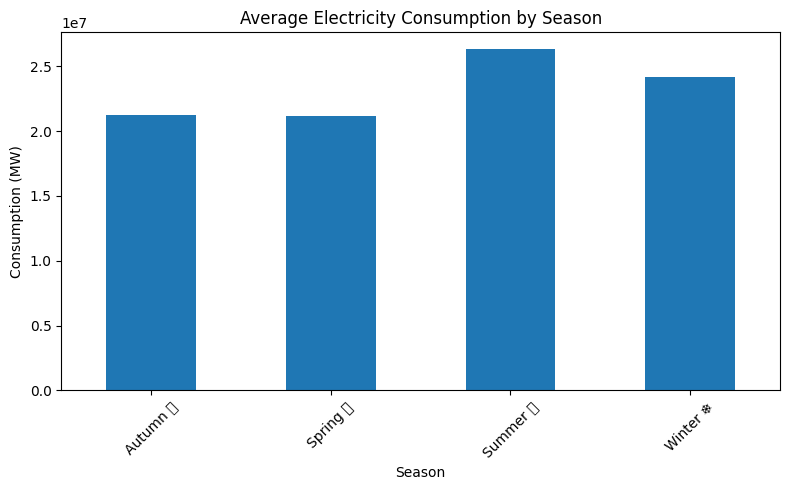

In [119]:
season_avg = df_clean.groupby("Season")["Total Consumption (MW)"].mean()

plt.figure(figsize=(8,5))

season_avg.plot(kind="bar")

plt.title("Average Electricity Consumption by Season")
plt.xlabel("Season")
plt.ylabel("Consumption (MW)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("images/season_chart.png")

plt.show()

Generate FINAL PDF (Professional)

In [116]:
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, Image
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()
doc = SimpleDocTemplate("Final_Smart_Grid_Report.pdf", pagesize=letter)

elements = []

# Title
elements.append(Paragraph("AI Smart Grid Monitoring System Report", styles['Title']))
elements.append(Spacer(1, 12))

# Description
elements.append(Paragraph(
    "This report analyzes electricity consumption trends over a 10-year period. "
    "The objective is to identify peak demand periods and seasonal patterns using time-series analysis. "
    "The results show that electricity demand consistently peaks during summer months due to increased cooling usage.",
    styles['BodyText']
))
elements.append(Spacer(1, 20))

# Peak Table
elements.append(Paragraph("Peak Electricity Consumption by Year", styles['Heading2']))
peak_data = [peak_table.columns.tolist()] + peak_table.values.tolist()

table1 = Table(peak_data)
table1.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.grey),
    ('TEXTCOLOR', (0,0), (-1,0), colors.whitesmoke),
    ('GRID', (0,0), (-1,-1), 0.5, colors.black)
]))
elements.append(table1)
elements.append(Spacer(1, 20))

# Seasonal Summary
elements.append(Paragraph("Seasonal Consumption Summary", styles['Heading2']))
season_data = [season_summary.columns.tolist()] + season_summary.values.tolist()

table2 = Table(season_data)
table2.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.grey),
    ('TEXTCOLOR', (0,0), (-1,0), colors.whitesmoke),
    ('GRID', (0,0), (-1,-1), 0.5, colors.black)
]))
elements.append(table2)
elements.append(Spacer(1, 20))

# Chart
elements.append(Paragraph("Seasonal Consumption Visualization", styles['Heading2']))
elements.append(Image("season_chart.png", width=400, height=250))
elements.append(Spacer(1, 20))

# Final Insight
elements.append(Paragraph(
    "Conclusion: The analysis confirms that electricity consumption is highest during summer months. "
    "This is due to increased use of cooling systems such as air conditioning. "
    "The findings demonstrate the effectiveness of AI-based time-series analysis in understanding energy demand patterns.",
    styles['BodyText']
))

doc.build(elements)

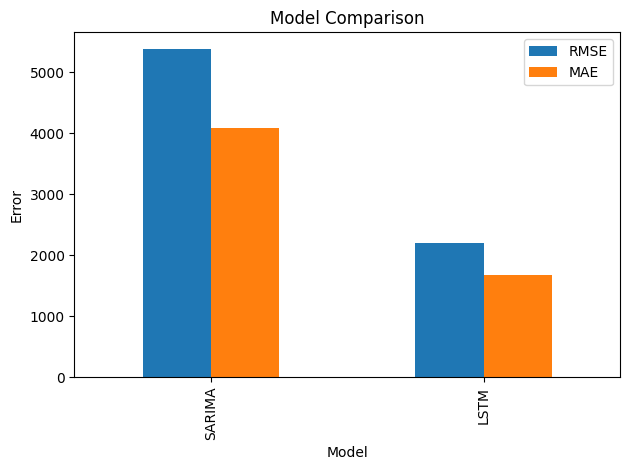

In [120]:
import pandas as pd

models = ["SARIMA", "LSTM"]
rmse = [5388, 2194]
mae = [4092, 1682]

df_compare = pd.DataFrame({
    "Model": models,
    "RMSE": rmse,
    "MAE": mae
})

df_compare.set_index("Model").plot(kind="bar")

plt.title("Model Comparison")
plt.ylabel("Error")

plt.tight_layout()

plt.savefig("images/model_comparison.png")

plt.show()

<Figure size 800x500 with 0 Axes>

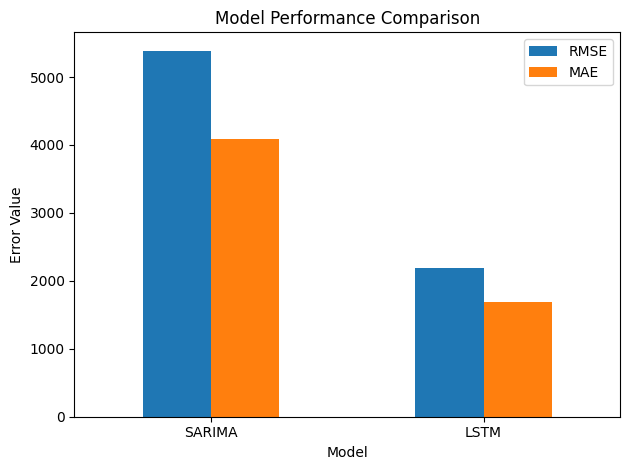

In [121]:
import matplotlib.pyplot as plt
import pandas as pd

models = ["SARIMA", "LSTM"]
rmse = [5388, 2194]
mae = [4092, 1682]

df_compare = pd.DataFrame({
    "Model": models,
    "RMSE": rmse,
    "MAE": mae
})

plt.figure(figsize=(8,5))

df_compare.set_index("Model").plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Error Value")
plt.xlabel("Model")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("images/model_performance.png")

plt.show()